**Students Grade Classification (One Vs All - OvA)**

Importing Libraries

In [43]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

**Task 1: Dataset Loading and Exploration**

In [44]:
df = pd.read_csv('students_data.csv')

In [45]:
df.shape

(500, 15)

In [46]:
df.head()

,age,num_notebooks,num_friends,travel_time,chai_cups_daily,total_f_grades,hangouts,societies,TAships,health,absences,times_cheated,study_time,love_for_ai/ml,grade
0,21,4,2,1,3,3,4,4,5,3,14,8,7,2,E
1,20,2,3,4,3,1,5,1,1,3,16,15,12,11,B
2,21,0,0,4,3,0,4,2,2,5,16,11,10,8,C
3,17,0,1,3,3,1,3,4,4,2,13,10,10,6,E
4,19,1,0,4,3,0,3,2,2,4,4,12,14,12,B


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              500 non-null    int64 
 1   num_notebooks    500 non-null    int64 
 2   num_friends      500 non-null    int64 
 3   travel_time      500 non-null    int64 
 4   chai_cups_daily  500 non-null    int64 
 5   total_f_grades   500 non-null    int64 
 6   hangouts         500 non-null    int64 
 7   societies        500 non-null    int64 
 8   TAships          500 non-null    int64 
 9   health           500 non-null    int64 
 10  absences         500 non-null    int64 
 11  times_cheated    500 non-null    int64 
 12  study_time       500 non-null    int64 
 13  love_for_ai/ml   500 non-null    int64 
 14  grade            500 non-null    object
dtypes: int64(14), object(1)
memory usage: 58.7+ KB


In [48]:
df.describe(include='all')

,age,num_notebooks,num_friends,travel_time,chai_cups_daily,total_f_grades,hangouts,societies,TAships,health,absences,times_cheated,study_time,love_for_ai/ml,grade
count,500.000000,500.00000,500.00000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,143
mean,18.052000,1.98800,2.05600,2.524000,2.482000,0.67800,2.986000,2.930000,2.924000,2.994000,8.542000,11.944000,12.578000,9.490000,NaN
std,2.049805,1.41982,1.41735,1.078773,1.119009,0.89885,1.399185,1.381636,1.383493,1.399243,6.136738,2.474087,2.416525,2.987264,NaN
min,15.000000,0.00000,0.00000,1.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,0.000000,4.000000,5.000000,0.000000,NaN
25%,16.000000,1.00000,1.00000,2.000000,1.000000,0.00000,2.000000,2.000000,2.000000,2.000000,4.000000,10.000000,11.000000,7.750000,NaN
50%,18.000000,2.00000,2.00000,3.000000,2.000000,0.00000,3.000000,3.000000,3.000000,3.000000,8.000000,12.000000,12.500000,9.000000,NaN
75%,20.000000,3.00000,3.00000,3.000000,3.000000,1.00000,4.000000,4.000000,4.000000,4.000000,13.000000,14.000000,14.000000,12.000000,NaN


In [49]:
df.dtypes

age                 int64
num_notebooks       int64
num_friends         int64
travel_time         int64
chai_cups_daily     int64
total_f_grades      int64
hangouts            int64
societies           int64
TAships             int64
health              int64
absences            int64
times_cheated       int64
study_time          int64
love_for_ai/ml      int64
grade              object
dtype: object

In [50]:
df['grade'].value_counts()

grade
C    143
B    132
A     90
D     86
E     49
Name: count, dtype: int64

**Task 2: Data Preprocessing**

In [51]:
X = df.drop(columns='grade')
y = df['grade']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [53]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (400, 14)
X_test shape: (100, 14)
y_train shape: (400,)
y_test shape: (100,)


In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (400, 14)
Scaled testing shape: (100, 14)


**Task 3: Manual Implementation**

In [56]:
class RegularizedLogisticRegression:
    def __init__(self, lr = 0.01, iterations = 1000):
        self.lr = lr
        self.iterations = iterations

    def sigmoid(self, z):
        return 1/(1 + np.exp(-z))

    def cross_entropy_loss(self, y_true, y_pred):
        m = len(y_true)
        loss = -(1/m)*np.sum(y_true*np.log(y_pred) + (1 - y_true)*np.log(1 - y_pred))
        return loss

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        self.losses = []

        for _ in range(self.iterations):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(z)

            dw = (1/m) * np.dot(X.T, (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = self.cross_entropy_loss(y, y_pred)
            self.losses.append(loss)

    def predict(self, X): 
        z = np.dot(X, self.weights) + self.bias 
        y_pred = self.sigmoid(z) 
        return y_pred, (y_pred >= 0.5).astype(int)

    def evaluate(self, y_true, y_pred_labels):
        acc = accuracy_score(y_true, y_pred_labels) 
        f1 = f1_score(y_true, y_pred_labels) 
        cm = confusion_matrix(y_true, y_pred_labels) 
        return acc, f1, cm

In [57]:
classifiers = {}
loss_history = {}

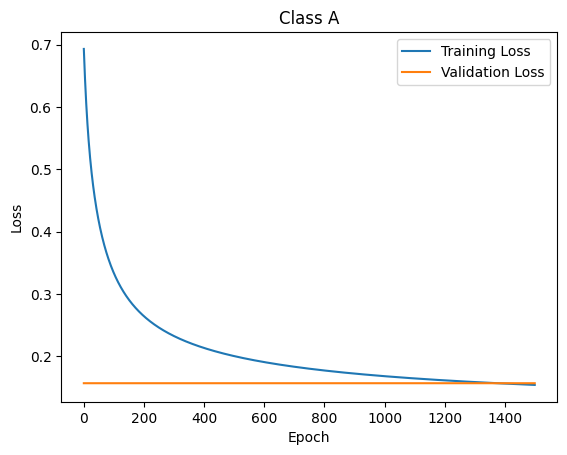

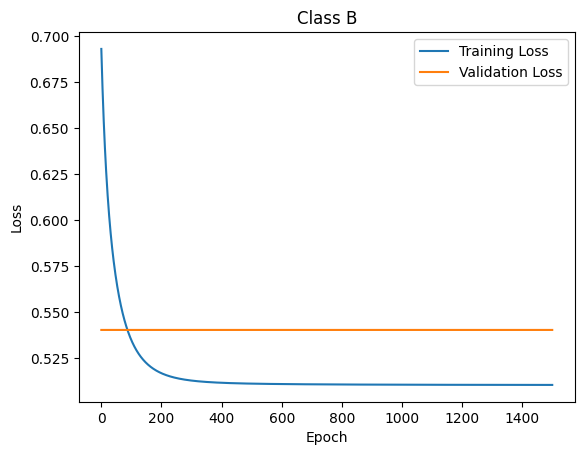

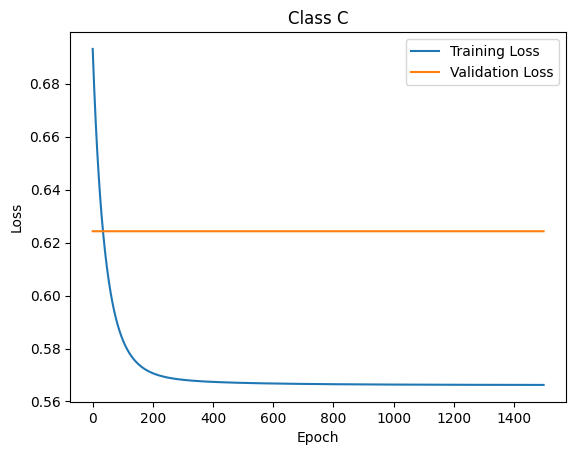

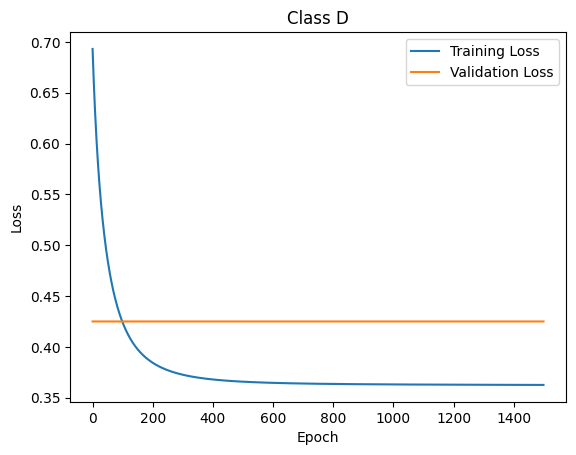

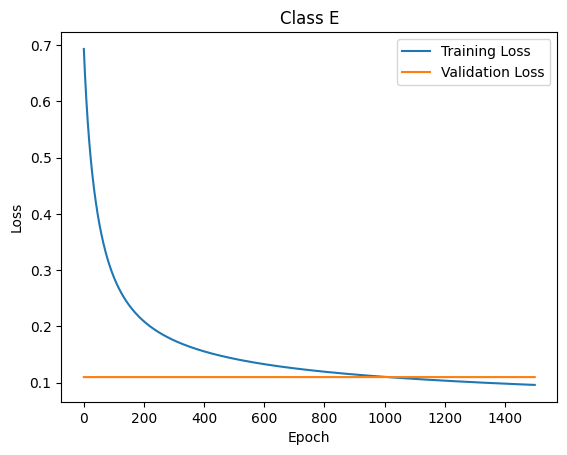

In [58]:
unique_grades = sorted(np.unique(y_train))

for current in unique_grades:
    y_train_new = np.where(y_train == current, 1, 0)
    y_binary = np.where(y_test == current, 1, 0)

    model = RegularizedLogisticRegression(lr = 0.05, iterations = 1500)

    model.fit(X_train_scaled, y_train_new)

    classifiers[current] = model

    losses_value = []

    for epoch in range(len(model.losses)):
        z_val = np.dot(X_test_scaled, model.weights) + model.bias
        y_pred_new = model.sigmoid(z_val)
        val_loss = model.cross_entropy_loss(y_binary, y_pred_new)
        losses_value.append(val_loss)
    
    loss_history[current] = (model.losses, losses_value)

    plt.figure()
    plt.plot(model.losses, label="Training Loss")
    plt.plot(losses_value, label="Validation Loss")
    plt.title(f"Class {current}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

**Task 4: Evaluation**

Grade A: Accuracy=0.9500, F1-Score=0.8571


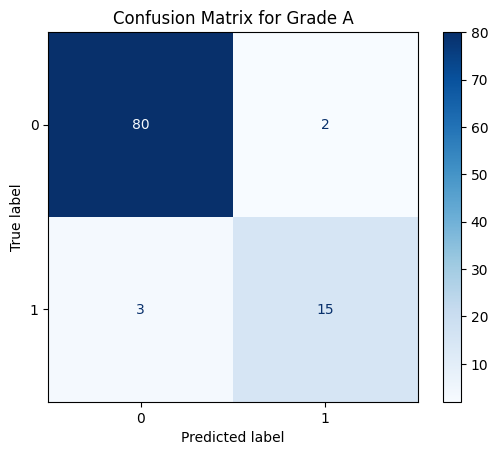

Grade B: Accuracy=0.6700, F1-Score=0.1081


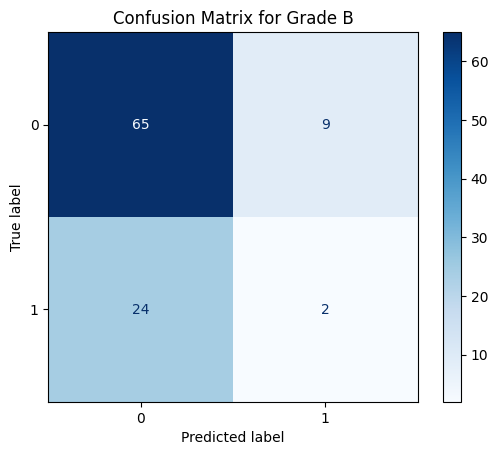

Grade C: Accuracy=0.6600, F1-Score=0.0000


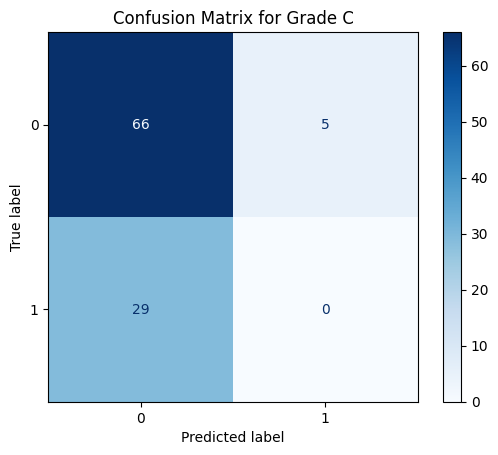

Grade D: Accuracy=0.7700, F1-Score=0.0800


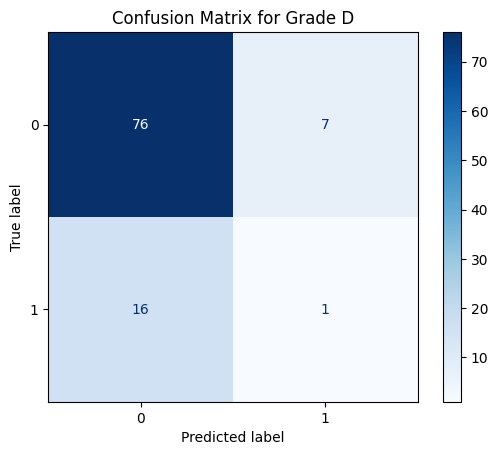

Grade E: Accuracy=0.9700, F1-Score=0.8235


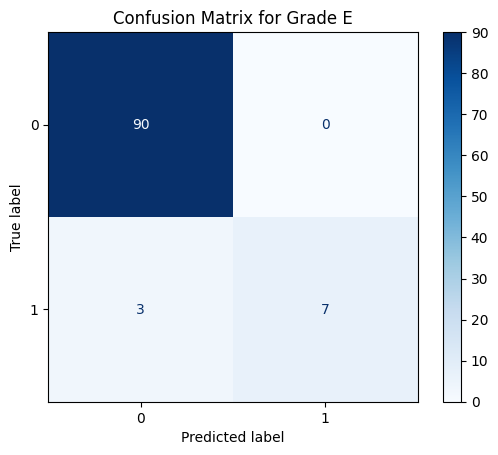

In [59]:
for current in unique_grades:
    model = classifiers[current]
    y_test_binary = np.where(y_test == current, 1, 0)
    y_pred_proba, y_pred_labels = model.predict(X_test_scaled)
    acc, f1, cm = model.evaluate(y_test_binary, y_pred_labels)
    print(f"Grade {current}: Accuracy={acc:.4f}, F1-Score={f1:.4f}")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix for Grade {current}")
    plt.show()

Multiclass Evaluation: Accuracy=0.6200, Macro F1-Score=0.6234

Confusion Matrix (counts):
[[16  2  0  0  0]
 [ 5 15  5  1  0]
 [ 0 10 19  0  0]
 [ 0  0 10  5  2]
 [ 0  0  1  2  7]]


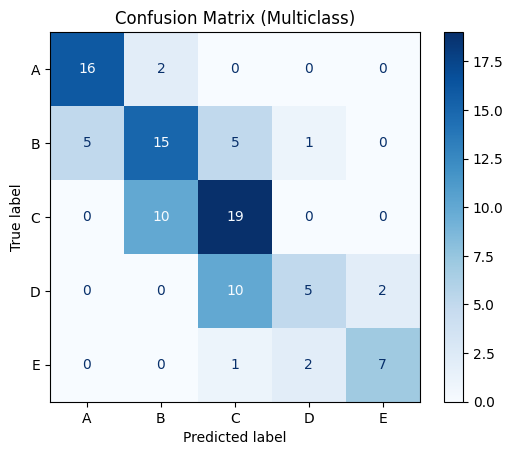

In [69]:
all_probs = np.zeros((X_test_scaled.shape[0], len(unique_grades)))
for idx, current in enumerate(unique_grades):
    model = classifiers[current]
    probs, _ = model.predict(X_test_scaled)
    all_probs[:, idx] = probs

pred_indices = np.argmax(all_probs, axis=1)
final_preds = np.array([unique_grades[i] for i in pred_indices])

n_correct = np.sum(final_preds == y_test)
accuracy = n_correct / len(y_test)
macro_f1 = f1_score(y_test, final_preds, average='macro')
cm_multiclass = confusion_matrix(y_test, final_preds)

print(f"Multiclass Evaluation: Accuracy={accuracy:.4f}, Macro F1-Score={macro_f1:.4f}")
print("\nConfusion Matrix (counts):")
print(cm_multiclass)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_multiclass, display_labels=unique_grades)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix (Multiclass)")
plt.show()

**Task 5: Sklearn Comparison**

Sklearn OvA Accuracy: 0.64
Sklearn OvA Macro F1: 0.6583973926079189
Sklearn OvA Confusion Matrix: 
 [[16  2  0  0  0]
 [ 3 16  6  1  0]
 [ 0 10 19  0  0]
 [ 0  0 11  5  1]
 [ 0  0  1  1  8]]


C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


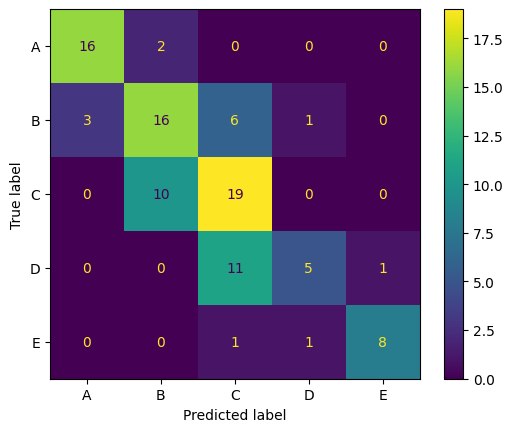

In [70]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, multi_class='ovr')
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

sklearn_acc = accuracy_score(y_test, y_pred)
sklearn_f1 = f1_score(y_test, y_pred, average='macro')

print("Sklearn OvA Accuracy:", sklearn_acc)
print("Sklearn OvA Macro F1:", sklearn_f1)
print("Sklearn OvA Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()